Libraries Used

In [4]:
import os
import random
from collections import Counter

import mne
import numpy as np
import pywt
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt
from mne import make_fixed_length_epochs

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

Determining the channels used for creating multi channel image, Patch size for dividing Scalogram image for proper training.

In [5]:
channels = [0, 1, 2]
patch_size = 32

train_data_path = "data"
test_data_path = "test_data"

In [6]:
def bandpass_filter(signal, fs):
    low = 8 / (fs / 2)
    high = 30 / (fs / 2)
    b, a = butter(4, [low, high], btype='band')
    return filtfilt(b, a, signal)

In [7]:
def generate_scalogram(signal, fs):
    scales = np.arange(1, 64)
    coeffs, _ = pywt.cwt(signal, scales, 'morl', 1/fs)
    scalogram = np.abs(coeffs)

    scalogram = (scalogram - np.min(scalogram)) / (np.max(scalogram) - np.min(scalogram) + 1e-8)

    return scalogram

In [8]:
def create_patches(scalogram, patch_size=32):
    patches = []
    h, w = scalogram.shape

    for i in range(0, h - patch_size, patch_size):
        for j in range(0, w - patch_size, patch_size):
            patch = scalogram[i:i+patch_size, j:j+patch_size]
            patches.append(patch)

    return patches

In [9]:
def process_file(file_path, label):
    raw = mne.io.read_raw_edf(file_path, preload=True)
    fs = int(raw.info['sfreq'])

    epochs = make_fixed_length_epochs(raw, duration=2.0, overlap=1.0)
    epochs_data = epochs.get_data()

    X = []
    y = []

    for epoch in epochs_data:

        epoch = (epoch - np.mean(epoch, axis=1, keepdims=True)) / (np.std(epoch, axis=1, keepdims=True) + 1e-8)

        # Filter all channels
        filtered = [bandpass_filter(ch, fs) for ch in epoch]
        filtered = np.array(filtered)

        # Generate scalograms per channel
        scalograms = [generate_scalogram(filtered[ch], fs) for ch in channels]

        # Create patches per channel
        channel_patches = [create_patches(s) for s in scalograms]

        # Combine patches across channels
        for i in range(len(channel_patches[0])):
            patch_stack = np.stack([
                channel_patches[0][i],
                channel_patches[1][i],
                channel_patches[2][i]
            ], axis=-1)

            X.append(patch_stack)
            y.append(label)

    return X, y

Registration For Training

In [10]:
X = []
y = []

user_folders = sorted(os.listdir(train_data_path))

for label, user in enumerate(user_folders):
    user_path = os.path.join(train_data_path, user)

    for file in os.listdir(user_path):
        if file.endswith(".edf"):
            file_path = os.path.join(user_path, file)
            Xi, yi = process_file(file_path, label)

            X.extend(Xi)
            y.extend(yi)

X = np.array(X)
y = np.array(y)

Extracting EDF parameters from data\S001\S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Not setting metadata
60 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 60 events and 320 original time points ...
0 bad epochs dropped
Extracting EDF parameters from data\S001\S001R02.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Not setting metadata
60 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 60 events and 320 original time points ...
0 bad epochs dropped
Extracting EDF parameters from data\S001\S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Not setting metadata
124 matching events found
No baseline corr

Deep Learning: CNN is Trained over registered users

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_classes = len(np.unique(y))

model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(patch_size, patch_size, 3)),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=16
)

c:\Users\yadav\OneDrive\Desktop\DSP\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6463 - loss: 1.1678 - val_accuracy: 0.7314 - val_loss: 0.8686
Epoch 2/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7010 - loss: 0.9187 - val_accuracy: 0.7504 - val_loss: 0.8045
Epoch 3/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7194 - loss: 0.8453 - val_accuracy: 0.7560 - val_loss: 0.7224
Epoch 4/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7250 - loss: 0.7926 - val_accuracy: 0.7651 - val_loss: 0.7375
Epoch 5/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7348 - loss: 0.7574 - val_accuracy: 0.7623 - val_loss: 0.6907
Epoch 6/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7492 - loss: 0.7205 - val_accuracy: 0.7819 - val_loss: 0.6213
Epoch 7/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7555 - loss: 0.6883 - val_accuracy: 0.7931 - val_loss: 0.5816
Epoch 8/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7675 - loss: 0.6591 - val_accur

Testing the data that is kept for testing during the training or testing over patch-level

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Accuracy: 0.8688639551192145
FAR: 0.04034927117012262
FRR: 0.23599146186262368


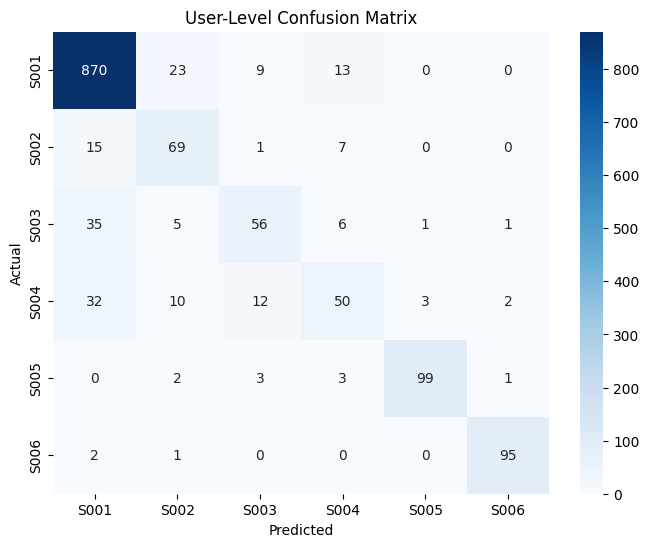

In [12]:
y_pred = np.argmax(model.predict(X_test), axis=1)

patch_cm = confusion_matrix(y_test, y_pred)

patch_accuracy = np.trace(patch_cm) / np.sum(patch_cm)

far_list = []

for i in range(len(patch_cm)):
    fp = np.sum(patch_cm[:, i]) - patch_cm[i, i]
    tn = np.sum(patch_cm) - (np.sum(patch_cm[i, :]) + np.sum(patch_cm[:, i]) - patch_cm[i, i])

    far = fp / (fp + tn + 1e-8)
    far_list.append(far)

FAR = np.mean(far_list)

frr_list = []

for i in range(len(patch_cm)):
    fn = np.sum(patch_cm[i, :]) - patch_cm[i, i]
    tp = patch_cm[i, i]

    frr = fn / (fn + tp + 1e-8)
    frr_list.append(frr)

FRR = np.mean(frr_list)

print("Accuracy:", patch_accuracy)
print("FAR:", FAR)
print("FRR:", FRR)

labels = user_folders

plt.figure(figsize=(8,6))

sns.heatmap(patch_cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("User-Level Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Performance matrix

In [13]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)
import time

start_time = time.time()

end_time = time.time()

latency = (end_time - start_time) / len(X_test)


precision = precision_score(
    y_test,
    y_pred,
    average='macro'
)

recall = recall_score(
    y_test,
    y_pred,
    average='macro'
)


f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)


mcc = matthews_corrcoef(y_test, y_pred)


specificity_list = []

for i in range(len(patch_cm)):

    tp = patch_cm[i, i]

    fp = np.sum(patch_cm[:, i]) - tp

    fn = np.sum(patch_cm[i, :]) - tp

    tn = np.sum(patch_cm) - (tp + fp + fn)

    specificity = tn / (tn + fp + 1e-8)

    specificity_list.append(specificity)

specificity = np.mean(specificity_list)


error_rate = 1 - patch_accuracy

y_prob = model.predict(X_test)

try:

    auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class='ovr'
    )

except:

    auc = "Not Available"

print("\n==============================")
print("PERFORMANCE METRICS")
print("==============================")

print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"Specificity   : {specificity:.4f}")
print(f"F1 Score      : {f1:.4f}")
print(f"MCC           : {mcc:.4f}")
print(f"Error Rate    : {error_rate:.4f}")
print(f"AUC-ROC       : {auc}")
print(f"Latency/sample: {latency:.6f} sec")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

PERFORMANCE METRICS
Precision     : 0.7974
Recall        : 0.7640
Specificity   : 0.9597
F1 Score      : 0.7757
MCC           : 0.7618
Error Rate    : 0.1311
AUC-ROC       : 0.9700730673161074
Latency/sample: 0.000000 sec


In [14]:
label_map = {i: user_folders[i] for i in range(len(user_folders))}

def authenticate_user(file_path):

    raw = mne.io.read_raw_edf(file_path, preload=True)
    fs = int(raw.info['sfreq'])

    epochs = make_fixed_length_epochs(raw, duration=2.0, overlap=1.0)
    epochs_data = epochs.get_data()

    predictions = []

    for epoch in epochs_data:

        # Normalize
        epoch = (epoch - np.mean(epoch, axis=1, keepdims=True)) / \
                (np.std(epoch, axis=1, keepdims=True) + 1e-8)

        # Filter
        filtered = [bandpass_filter(ch, fs) for ch in epoch]
        filtered = np.array(filtered)

        # Scalograms
        scalograms = [generate_scalogram(filtered[ch], fs) for ch in channels]

        # Patches
        channel_patches = [create_patches(s) for s in scalograms]

        for i in range(len(channel_patches[0])):

            patch_stack = np.stack([
                channel_patches[0][i],
                channel_patches[1][i],
                channel_patches[2][i]
            ], axis=-1)

            patch_stack = np.expand_dims(patch_stack, axis=0)

            pred = model.predict(patch_stack, verbose=0)[0]

            pred_class = np.argmax(pred)

            predictions.append(pred_class)

    counter = Counter(predictions)

    final_class = counter.most_common(1)[0][0]
    votes = counter.most_common(1)[0][1]

    vote_ratio = votes / len(predictions)

    if vote_ratio < 0.75:
        return "Unauthorized", None
    else:
        return "Authorized", label_map[final_class]

Registration of test data for testing some users

In [15]:
true_labels = []
predicted_labels = []

test_users = sorted(os.listdir(test_data_path))

for user in test_users:
    user_test_path = os.path.join(test_data_path, user)

    for file in os.listdir(user_test_path):
        if file.endswith(".edf"):
            file_path = os.path.join(user_test_path, file)
            status, predicted_user = authenticate_user(file_path)

            if user in user_folders:
                true_labels.append(user)
            else:
                true_labels.append("Unauthorized")

            if status == "Unauthorized":
                predicted_labels.append("Unauthorized")
            else:
                predicted_labels.append(predicted_user)

all_labels = user_folders + ["Unauthorized"]

user_cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=all_labels
)

Extracting EDF parameters from test_data\S001\S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Not setting metadata
60 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 60 events and 320 original time points ...
0 bad epochs dropped
Extracting EDF parameters from test_data\S001\S001R02.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Not setting metadata
60 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 60 events and 320 original time points ...
0 bad epochs dropped
Extracting EDF parameters from test_data\S001\S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Not setting metadata
124 matching events found
N

Forming confusion matrix over Test user

User-Level Accuracy: 0.8


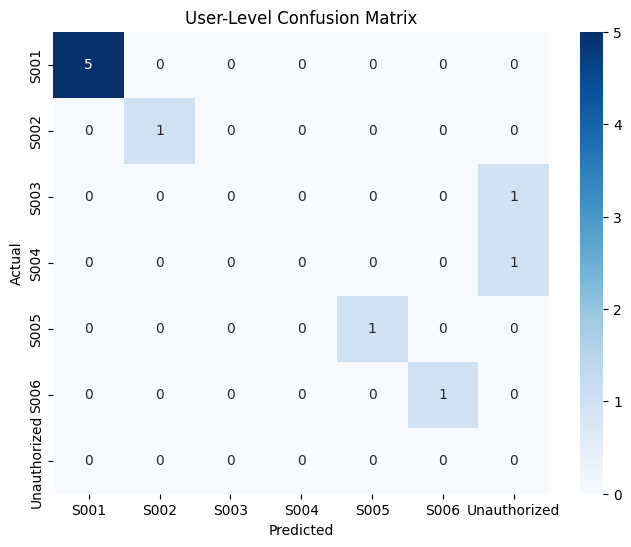

In [16]:
user_accuracy = np.trace(user_cm) / np.sum(user_cm)

print("User-Level Accuracy:", user_accuracy)

plt.figure(figsize=(8,6))

sns.heatmap(user_cm, annot=True, fmt='d', cmap='Blues', xticklabels=all_labels, yticklabels=all_labels)
plt.title("User-Level Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Testing: Final Output

In [ ]:
test_file = "data\\S001\\S001R01.edf"

status, user = authenticate_user(test_file)

if status == "Authorized":
    print(f"{user} - Authorized")
else:
    print("Unauthorized")

Extracting EDF parameters from S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Not setting metadata
60 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 60 events and 320 original time points ...
0 bad epochs dropped
S001 - Authorized
